# klue/roberta-base 텍스트 분류 학습
B2, P 멀티모달 모델 RoBERTa 초기 가중치용
백본 동결 + 분류 헤드만 학습 (전이학습)

## 0. 환경 설정

In [ ]:
!pip install tf_keras tensorflow_hub scikit-learn -q
!pip install transformers==4.40.0 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 128.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.5.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tf_keras as keras
from tf_keras import layers
import tensorflow as tf
from transformers import AutoTokenizer, TFRobertaModel

from sklearn.metrics import accuracy_score, f1_score, classification_report

print('TensorFlow 버전:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow 버전: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. 드라이브 마운트 및 경로 설정

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_DIR = '/content/drive/MyDrive/multimodel_recycle/output'
TRAIN_CSV = os.path.join(BASE_DIR, 'train.csv')
VAL_CSV = os.path.join(BASE_DIR, 'val.csv')
TEST_CSV = os.path.join(BASE_DIR, 'test.csv')

# 하이퍼파라미터
BATCH_SIZE = 32
EPOCHS = 50
LR = 2e-5
NUM_CLASS = 23
MAX_LEN = 64
SEED = 42

GROUP_NAMES = {
    0:  '종이', 1:  '종이팩', 2:  '종이컵', 3:  '캔',
    4:  '재사용유리', 5:  '유리', 6:  '페트', 7:  '플라스틱', 8:  '비닐',
    9:  '종이+이물질', 10: '종이컵+이물질', 11: '캔+이물질', 12: '유리+이물질',
    13: '페트+이물질+다중포장재', 14: '페트+이물질', 15: '플라스틱+이물질', 16: '비닐+이물질',
    17: '재사용유리+다중포장재', 18: '유리+다중포장재', 19: '페트+다중포장재',
    20: '스티로폼', 21: '스티로폼+이물질', 22: '건전지',
}
print('설정 완료')

설정 완료


## 2. 데이터 로드 및 토크나이징

In [ ]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print(f'Train: {len(train_df)}장')
print(f'Val:   {len(val_df)}장')
print(f'Test:  {len(test_df)}장')

Train: 17250장
Val:   3450장
Test:  2300장


In [ ]:
# Hugging Face에서 klue/roberta-base 로드
tokenizer = AutoTokenizer.from_pretrained('klue/roberta-base')

def tokenize_texts(texts):
    encoded = tokenizer(
        list(texts),
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )
    return encoded['input_ids'], encoded['attention_mask']

train_input_ids, train_attn_mask = tokenize_texts(train_df['bert_text'])
val_input_ids, val_attn_mask = tokenize_texts(val_df['bert_text'])
test_input_ids, test_attn_mask = tokenize_texts(test_df['bert_text'])


print('토크나이징 완료')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

토크나이징 완료


## 3. Dataset 생성

In [ ]:
def make_text_dataset(df, input_ids, attn_mask, shuffle=False):
    labels = df['group_id'].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((
        {'input_ids': input_ids.numpy(), 'attention_mask': attn_mask.numpy()},
        labels
    ))
    if shuffle:
        ds = ds.shuffle(buffer_size=1000, seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_text_dataset(train_df, train_input_ids, train_attn_mask, shuffle=True)
val_ds = make_text_dataset(val_df,   val_input_ids,   val_attn_mask)
test_ds = make_text_dataset(test_df,  test_input_ids,  test_attn_mask)

print('Dataset 생성 완료')

Dataset 생성 완료


## 4. Roberta 모델 구성 (전이학습 - 백본 동결)

In [ ]:
# klue/roberta-base: 한국어 특화 RoBERTa
roberta = TFRobertaModel.from_pretrained('klue/roberta-base', from_pt=True)
roberta.trainable = False  # 백본 동결 (전이학습)

input_ids_input = keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='input_ids')
attn_mask_input = keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='attention_mask')

txt_output = roberta(input_ids=input_ids_input, attention_mask=attn_mask_input)
cls_token = txt_output.last_hidden_state[:, 0, :]  # [CLS] 토큰 (batch, 768)

x = layers.Dense(256, activation='relu')(cls_token)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASS, activation='softmax')(x)

model_rt = keras.Model(
    inputs={'input_ids': input_ids_input, 'attention_mask': attn_mask_input},
    outputs=outputs,
    name='RT_RoBERTa'
)
model_rt.summary()

config.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaModel: ['lm_head.dense.weight', 'lm_head.decoder.bias', 'lm_head.layer_norm.bias', 'lm_head.dense.bias', 'roberta.embeddings.position_ids', 'lm_head.layer_norm.weight', 'lm_head.decoder.weight', 'lm_head.bias']
- This IS expected if you are initializing TFRobertaModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaModel were not initialized from the PyTorch model and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream 

Model: "RT_RoBERTa"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 64)]                 0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 64)]                 0         []                            
 )                                                                                                
                                                                                                  
 tf_roberta_model (TFRobert  TFBaseModelOutputWithPooli   1106181   ['input_ids[0][0]',           
 aModel)                     ngAndCrossAttentions(last_   12         'attention_mask[0][0]']      
                             hidden_state=(None, 64, 76                                  

## 5. 모델 학습

In [ ]:
model_rt.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=LR, weight_decay=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    keras.callbacks.ModelCheckpoint('rt_best.keras', save_best_only=True, monitor='val_loss'),
]

hist = model_rt.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks
)

Epoch 1/50
539/540 [============================>.] - ETA: 0s - loss: 3.1968 - accuracy: 0.0472

/usr/local/lib/python3.12/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


540/540 [==============================] - 37s 44ms/step - loss: 3.1968 - accuracy: 0.0472 - val_loss: 3.1027 - val_accuracy: 0.0855
Epoch 2/50
540/540 [==============================] - 20s 38ms/step - loss: 3.1248 - accuracy: 0.0605 - val_loss: 3.0647 - val_accuracy: 0.1652
Epoch 3/50
540/540 [==============================] - 21s 38ms/step - loss: 3.0776 - accuracy: 0.0806 - val_loss: 3.0257 - val_accuracy: 0.1730
Epoch 4/50
540/540 [==============================] - 21s 38ms/step - loss: 3.0317 - accuracy: 0.0986 - val_loss: 2.9828 - val_accuracy: 0.2246
Epoch 5/50
540/540 [==============================] - 20s 38ms/step - loss: 2.9898 - accuracy: 0.1139 - val_loss: 2.9390 - val_accuracy: 0.2191
Epoch 6/50
540/540 [==============================] - 20s 36ms/step - loss: 2.9457 - accuracy: 0.1242 - val_loss: 2.8933 - val_accuracy: 0.2171
Epoch 7/50
540/540 [==============================] - 20s 38ms/step - loss: 2.8985 - accuracy: 0.1416 - val_loss: 2.8439 - val_accuracy: 0.2333
Epo

## 6. 학습 곡선 시각화

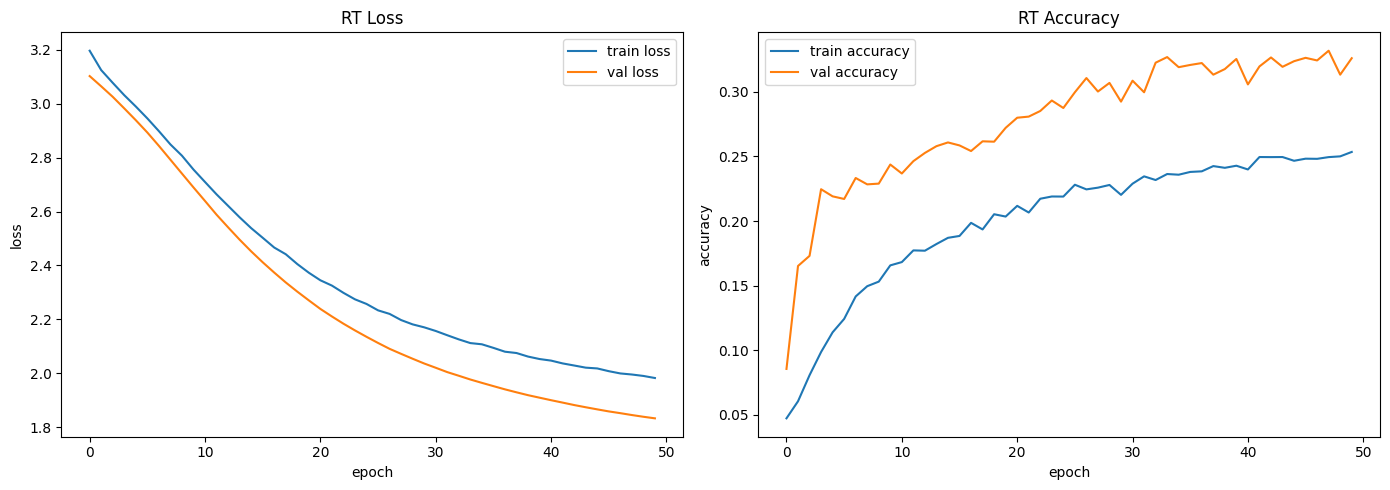

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(hist.history['loss'], label='train loss')
axs[0].plot(hist.history['val_loss'], label='val loss')
axs[0].set_xlabel('epoch')
axs[0].set_ylabel('loss')
axs[0].set_title('RT Loss')
axs[0].legend()

axs[1].plot(hist.history['accuracy'], label='train accuracy')
axs[1].plot(hist.history['val_accuracy'], label='val accuracy')
axs[1].set_xlabel('epoch')
axs[1].set_ylabel('accuracy')
axs[1].set_title('RT Accuracy')
axs[1].legend()

plt.tight_layout()
plt.savefig('rt_training_curve.png', dpi=150)
plt.show()

## 7. RoBERTa 가중치 저장 (P 로드용)

In [ ]:
# B2, P에서 불러올 RoBERTa 가중치 저장
roberta_save_path = os.path.join(BASE_DIR, 'roberta_finetuned')
roberta.save_pretrained(roberta_save_path)
tokenizer.save_pretrained(roberta_save_path)

print(f'RoBERTa 가중치 저장 완료: {roberta_save_path}')

RoBERTa 가중치 저장 완료: /content/drive/MyDrive/multimodel_recycle/output/roberta_finetuned
